In [1]:
pip install econml

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv('final.csv')

In [8]:
# Datetime handling
df["datetime"] = pd.to_datetime(df["datetime"])

df = df[df["datetime"].dt.year == 2025].copy()

# Feature
df['hour'] = df['datetime'].dt.hour

# Drop NaN
df = df.dropna()

In [9]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["datetime"].dt.month.apply(get_season)

In [22]:
results = []

seasons = ["Winter", "Summer", "Monsoon", "Autumn"]

for season in seasons:

    print("Processing:", season)  # DEBUG

    df_season = df[df["Season"] == season].copy()

    df_season = df_season.dropna(subset=["wdLoad", "temp", "rh", "hour"])

    if len(df_season) < 50:
        continue

    Y = df_season["wdLoad"].values

    # CASE 1
    T = df_season["temp"].values
    X = df_season[["hour", "rh"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        n_estimators=100,
        min_samples_leaf=10,
        random_state=42
    )

    model.fit(Y, T, X=X)

    results.append({
        "Season": season,
        "Case": "Temp → Load",
        "ATE": model.ate(X)
    })

    #Case 2
    T = df_season["rh"].values
    X = df_season[["temp", "hour"]].values

    model2 = CausalForestDML(
            model_y=RandomForestRegressor(),
            model_t=RandomForestRegressor(),
            n_estimators=100,
            min_samples_leaf=10,
            random_state=42
        )

    model2.fit(Y, T, X=X)
    ate2 = model2.ate(X)

    results.append({
            "Season": season,
            "Case": "RH → Load",
            "ATE": ate2
        })

    #case 3
    T = df_season["hour"].values
    X = df_season[["temp", "rh"]].values

    model3 = CausalForestDML(
            model_y=RandomForestRegressor(),
            model_t=RandomForestRegressor(),
            n_estimators=100,
            min_samples_leaf=10,
            random_state=42
        )

    model3.fit(Y, T, X=X)
    ate3 = model3.ate(X)

    results.append({
            "Season": season,
            "Case": "Hour → Load",
            "ATE": ate3
        })

    #Case 4
    T = df_season[["temp", "rh"]].values
    X = df_season[["hour"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        n_estimators=100,
        min_samples_leaf=10,
        random_state=42
    )

    model.fit(Y, T, X=X)

    # 🔥 Correct method
    effects = model.const_marginal_effect(X)

    # Take average across all samples
    avg_effect = effects.mean(axis=0)

    results.append({
        "Season": season,
        "Case": "Temp + RH → Load",
        "ATE_temp": avg_effect[0],
        "ATE_rh": avg_effect[1]
    })

Processing: Winter
Processing: Summer
Processing: Monsoon
Processing: Autumn


In [23]:
results_df = pd.DataFrame(results)
print(results_df)

     Season              Case        ATE   ATE_temp    ATE_rh
0    Winter       Temp → Load   2.257818        NaN       NaN
1    Winter         RH → Load   0.006270        NaN       NaN
2    Winter       Hour → Load  -3.410082        NaN       NaN
3    Winter  Temp + RH → Load        NaN   2.603130 -0.181709
4    Summer       Temp → Load  14.109822        NaN       NaN
5    Summer         RH → Load   1.030248        NaN       NaN
6    Summer       Hour → Load  -1.301692        NaN       NaN
7    Summer  Temp + RH → Load        NaN  12.706425  0.969913
8   Monsoon       Temp → Load  11.085858        NaN       NaN
9   Monsoon         RH → Load   0.038292        NaN       NaN
10  Monsoon       Hour → Load  -4.209831        NaN       NaN
11  Monsoon  Temp + RH → Load        NaN   9.765740  0.170538
12   Autumn       Temp → Load   9.749583        NaN       NaN
13   Autumn         RH → Load   0.918386        NaN       NaN
14   Autumn       Hour → Load  -1.498565        NaN       NaN
15   Aut

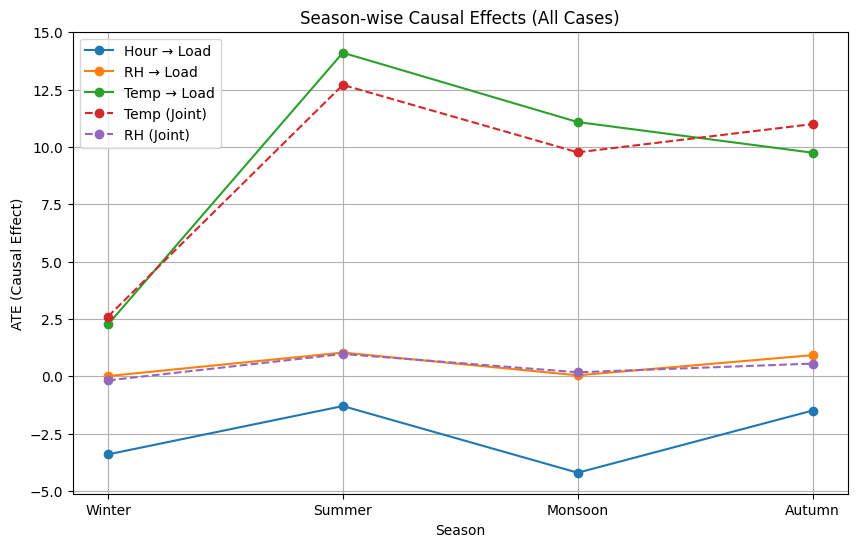

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# 🔹 Convert to DataFrame
# -------------------------------
results_df = pd.DataFrame(results)

# Ensure correct season order
season_order = ["Winter", "Summer", "Monsoon", "Autumn"]

# -------------------------------
# 🔹 Separate data
# -------------------------------
df_simple = results_df[results_df["Case"] != "Temp + RH → Load"]
df_case4 = results_df[results_df["Case"] == "Temp + RH → Load"]

# -------------------------------
# 🔹 Pivot for Cases 1–3
# -------------------------------
pivot_df = df_simple.pivot(index="Season", columns="Case", values="ATE")
pivot_df = pivot_df.loc[season_order]

# -------------------------------
# 🔹 Prepare Case 4
# -------------------------------
df_case4 = df_case4.set_index("Season").loc[season_order]

# -------------------------------
# 🔹 Plot
# -------------------------------
plt.figure(figsize=(10,6))

# Cases 1–3
for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], marker='o', label=col)

# Case 4 (Temp + RH split)
plt.plot(df_case4.index, df_case4["ATE_temp"], marker='o', linestyle='--', label="Temp (Joint)")
plt.plot(df_case4.index, df_case4["ATE_rh"], marker='o', linestyle='--', label="RH (Joint)")

# -------------------------------
# 🔹 Labels
# -------------------------------
plt.xlabel("Season")
plt.ylabel("ATE (Causal Effect)")
plt.title("Season-wise Causal Effects (All Cases)")

plt.legend()
plt.grid()

plt.show()

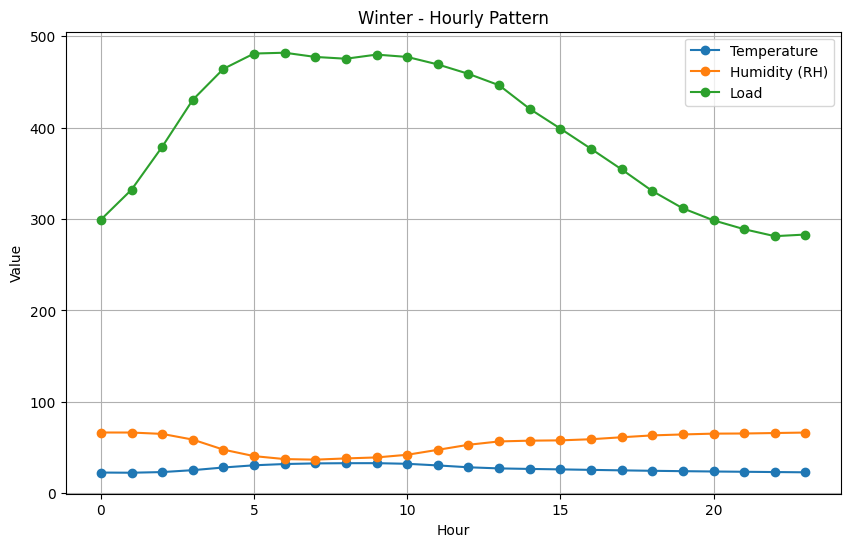

In [26]:
df_winter = df[(df["datetime"].dt.year == 2025) & (df["datetime"].dt.month.isin([12,1,2]))].copy()

df_winter["hour"] = df_winter["datetime"].dt.hour

grouped = df_winter.groupby("hour")[["temp","rh","wdLoad"]].mean().reset_index()

plt.figure(figsize=(10,6))

plt.plot(grouped["hour"], grouped["temp"], marker='o', label="Temperature")
plt.plot(grouped["hour"], grouped["rh"], marker='o', label="Humidity (RH)")
plt.plot(grouped["hour"], grouped["wdLoad"], marker='o', label="Load")

plt.xlabel("Hour")
plt.ylabel("Value")
plt.title("Winter - Hourly Pattern")

plt.legend()
plt.grid()
plt.show()

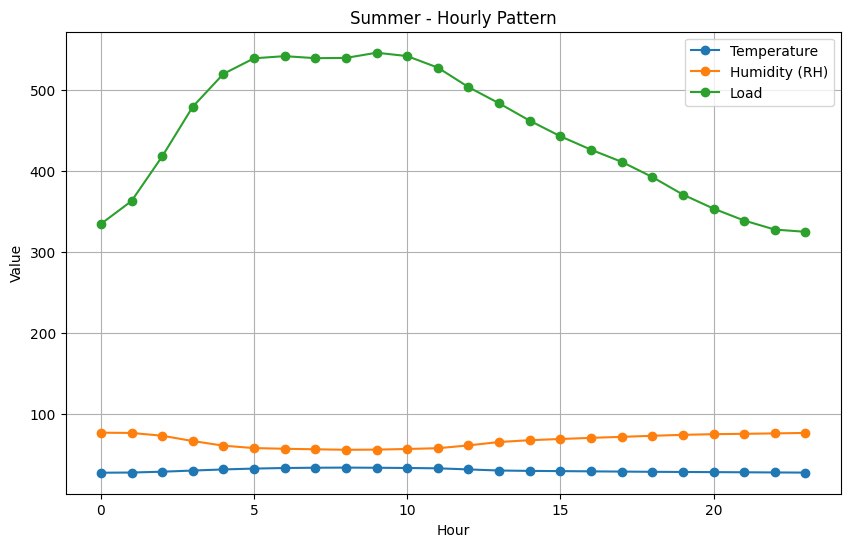

In [28]:
df_summer = df[(df["datetime"].dt.year == 2025) & (df["datetime"].dt.month.isin([3,4,5]))].copy()

df_summer["hour"] = df_summer["datetime"].dt.hour

grouped = df_summer.groupby("hour")[["temp","rh","wdLoad"]].mean().reset_index()

plt.figure(figsize=(10,6))

plt.plot(grouped["hour"], grouped["temp"], marker='o', label="Temperature")
plt.plot(grouped["hour"], grouped["rh"], marker='o', label="Humidity (RH)")
plt.plot(grouped["hour"], grouped["wdLoad"], marker='o', label="Load")

plt.xlabel("Hour")
plt.ylabel("Value")
plt.title("Summer - Hourly Pattern")

plt.legend()
plt.grid()
plt.show()

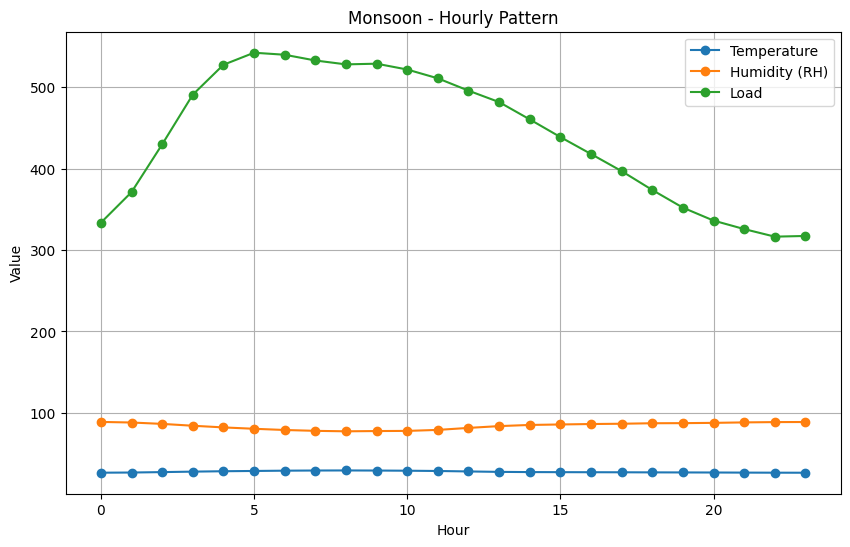

In [29]:
df_monsoon = df[(df["datetime"].dt.year == 2025) & (df["datetime"].dt.month.isin([6,7,8,9]))].copy()

df_monsoon["hour"] = df_monsoon["datetime"].dt.hour

grouped = df_monsoon.groupby("hour")[["temp","rh","wdLoad"]].mean().reset_index()

plt.figure(figsize=(10,6))

plt.plot(grouped["hour"], grouped["temp"], marker='o', label="Temperature")
plt.plot(grouped["hour"], grouped["rh"], marker='o', label="Humidity (RH)")
plt.plot(grouped["hour"], grouped["wdLoad"], marker='o', label="Load")

plt.xlabel("Hour")
plt.ylabel("Value")
plt.title("Monsoon - Hourly Pattern")

plt.legend()
plt.grid()
plt.show()

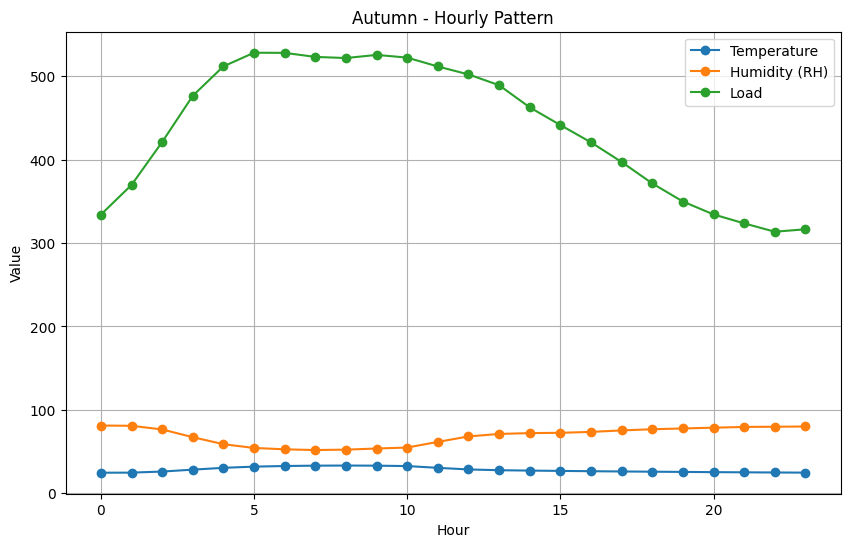

In [30]:
df_autumn = df[(df["datetime"].dt.year == 2025) & (df["datetime"].dt.month.isin([10,11]))].copy()

df_autumn["hour"] = df_autumn["datetime"].dt.hour

grouped = df_autumn.groupby("hour")[["temp","rh","wdLoad"]].mean().reset_index()

plt.figure(figsize=(10,6))

plt.plot(grouped["hour"], grouped["temp"], marker='o', label="Temperature")
plt.plot(grouped["hour"], grouped["rh"], marker='o', label="Humidity (RH)")
plt.plot(grouped["hour"], grouped["wdLoad"], marker='o', label="Load")

plt.xlabel("Hour")
plt.ylabel("Value")
plt.title("Autumn - Hourly Pattern")

plt.legend()
plt.grid()
plt.show()